In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.optimizers import SGD
from keras import backend as K
from sklearn.manifold import TSNE
import umap
from keras.datasets import mnist
from keras import utils
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

%matplotlib inline
plt.rcParams["animation.html"] = "jshtml"
 
nb_classes = 10

# Exercise 1: MNIST Visualization Using Hidden Layer Activations

In [2]:
def create_clasification_model():
    # Set dropout rate - fractions of neurons to drop
    dropout = 0.5

    # Build very simple neural network with 2 hidden layers
    model = Sequential()
    model.add(Dense(256, activation='relu', name="dense1"))
    model.add(Dropout(dropout, name="dropout1"))
    model.add(Dense(64, activation='relu', name="dense2"))
    model.add(Dropout(dropout, name="dropout2"))
    model.add(Dense(nb_classes, activation='softmax', name="dense3"))

    model.compile(loss='categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy'])
    return model

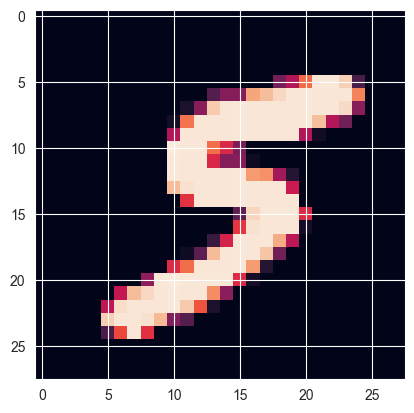

In [3]:
# The binary_crossentropy loss expects a one-hot-vector as input,
# so we apply the to_categorical function from keras.utils to convert integer labels to one-hot-vectors.
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Put everything on grayscale
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = utils.to_categorical(y_train, 10)
Y_test = utils.to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5/6)

# Show example digit
plt.imshow(X_train[0].reshape(28, 28))

In [4]:
# When we have defined and compiled the model, it can be trained using the fit function.
# We also use validation dataset to monitor validation loss and accuracy.
model = create_clasification_model()
network_history = model.fit(X_train, Y_train, batch_size=128,
                           epochs=20, verbose=1, validation_data=(X_val, Y_val))

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6479 - loss: 1.0682 - val_accuracy: 0.9350 - val_loss: 0.2240
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9028 - loss: 0.3361 - val_accuracy: 0.9513 - val_loss: 0.1651
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9277 - loss: 0.2591 - val_accuracy: 0.9602 - val_loss: 0.1397
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9415 - loss: 0.2082 - val_accuracy: 0.9639 - val_loss: 0.1279
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9471 - loss: 0.1883 - val_accuracy: 0.9662 - val_loss: 0.1151
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9510 - loss: 0.1693 - val_accuracy: 0.9683 - val_loss: 0.1048
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9553 - loss: 0.1584 - val_accuracy: 0.9715 - val_loss: 0.0991
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9586 - loss: 0.1458 - val_accuracy: 0.

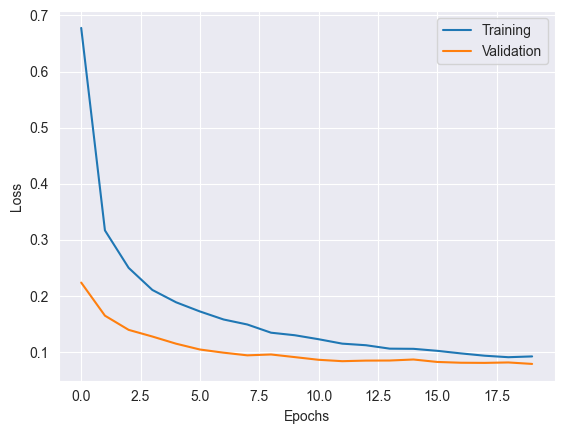

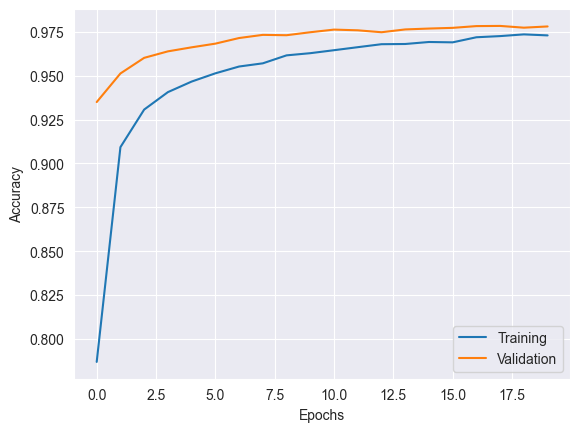

In [5]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(network_history.history['loss'])
    plt.plot(network_history.history['val_loss'])
    plt.legend(['Training', 'Validation'])

    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(network_history.history['accuracy'])
    plt.plot(network_history.history['val_accuracy'])
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

# The fit function returns a keras.callbacks.History object which contains the entire history
# of training/validation loss, accuracy and other metrics for each epoch.
# We can therefore plot the behavior of loss and accuracy during the training phase.
plot_history(network_history)

In [6]:
# Keras Model has the summary function that prints data about model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

In [7]:
def get_hidden_layers_acitvations(model, input):

    output_of_dense1 = model.get_layer('dense1')(input)
    output_of_dense2 = model.get_layer('dense2')(output_of_dense1)
    output_of_dense3 = model.get_layer('dense3')(output_of_dense2)
    return output_of_dense1, output_of_dense2, output_of_dense3


In [8]:
layer1_output_test, layer2_output_test, layer3_output_test = get_hidden_layers_acitvations(model, X_test)
layer1_output_train, layer2_output_train, layer3_output_train = get_hidden_layers_acitvations(model, X_train)


/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


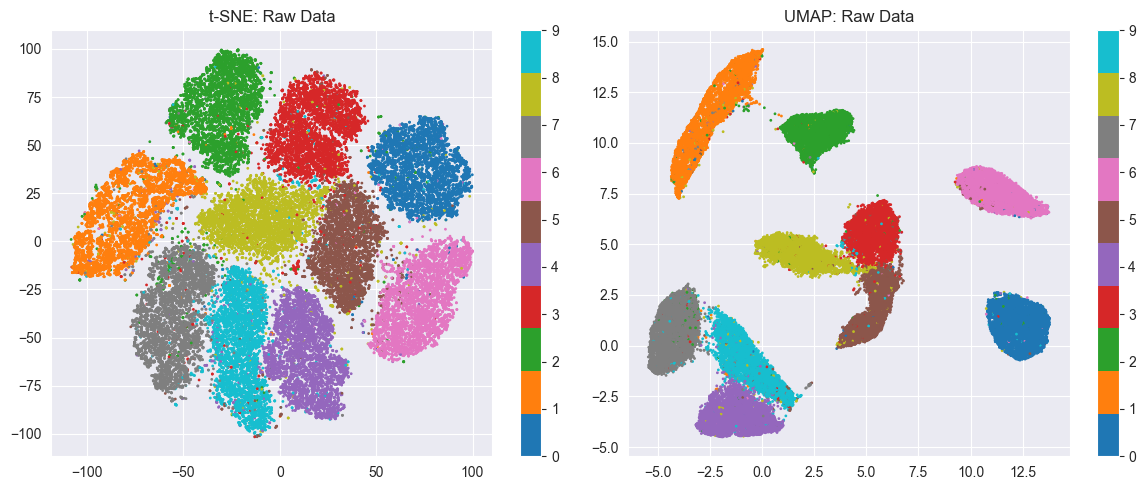

/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


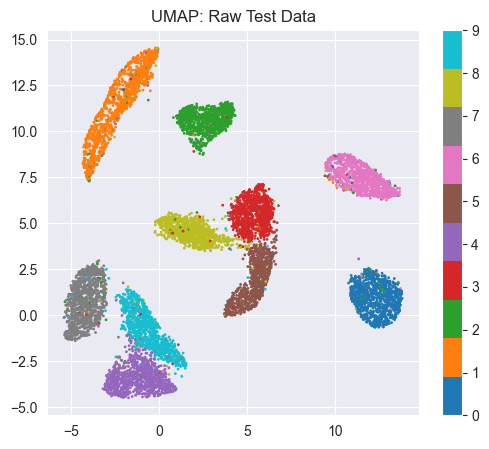

Raw Data UMAP Embeddings:
n_neighbors=1, Accuracy: 0.9297
n_neighbors=3, Accuracy: 0.9524
n_neighbors=5, Accuracy: 0.9550
n_neighbors=7, Accuracy: 0.9554
n_neighbors=10, Accuracy: 0.9555
n_neighbors=15, Accuracy: 0.9554


In [9]:
def evaluate_knn(X_train_embedded, X_test_embedded, y_train, y_test, n_neighbors_list):
    results = []
    for n_neighbors in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train_embedded, y_train)
        y_pred = knn.predict(X_test_embedded)
        accuracy = accuracy_score(y_test, y_pred)
        results.append((n_neighbors, accuracy))
        print(f"n_neighbors={n_neighbors}, Accuracy: {accuracy:.4f}")
    return results


def tsne_umap_raw_data(X_train,Y_train, n=5000):
    # Import other visualization techniques you need
    # X_train_small = X_train[:n]
    # Y_train_small = Y_train[:n]
    # X_test_small = X_test[:n]
    # Y_test_small = Y_test[:n]
    X_train_small = X_train
    Y_train_small = Y_train
    X_test_small = X_test
    Y_test_small = Y_test
    # Apply t-SNE to raw training data
    tsne = TSNE(n_components=2, random_state=42)
    X_train_tsne = tsne.fit_transform(X_train_small)

    # Apply UMAP to raw training data
    umap_model = umap.UMAP(n_components=2, random_state=42)
    X_train_umap = umap_model.fit_transform(X_train_small)

    # Visualize the embeddings
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=np.argmax(Y_train_small, axis=1), cmap='tab10', s=1)
    plt.title('t-SNE: Raw Data')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=np.argmax(Y_train_small, axis=1), cmap='tab10', s=1)
    plt.title('UMAP: Raw Data')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Apply UMAP transform to test data
    X_test_umap = umap_model.transform(X_test_small)

    # Visualize test data projection
    plt.figure(figsize=(6, 5))
    plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=np.argmax(Y_test_small, axis=1), cmap='tab10', s=1)
    plt.title('UMAP: Raw Test Data')
    plt.colorbar()
    plt.show()

    # Convert Y_train and Y_test to class labels
    y_train = np.argmax(Y_train, axis=1)
    y_test = np.argmax(Y_test, axis=1)

    # Test KNN with different numbers of neighbors
    n_neighbors_list = [1,3,5,7,10,15]

    print("Raw Data UMAP Embeddings:")
    raw_results = evaluate_knn(X_train_umap, X_test_umap, y_train, y_test, n_neighbors_list)

tsne_umap_raw_data(X_train,Y_train, n=5000)

In [10]:

def create_layer_visualization(Y_test, Y_train, layer_output_test, layer_output_train, title, n=5000):
    # Y_test_small = Y_test[:n]
    # test_layer_small = layer_output_test[:n]
    #
    # Y_train_small = Y_train[:n]
    # train_layer_small = layer_output_train[:n]
    Y_test_small = Y_test
    test_layer_small = layer_output_test

    Y_train_small = Y_train
    train_layer_small = layer_output_train

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_train_tsne = tsne.fit_transform(train_layer_small)

    # Apply umap
    umap_model = umap.UMAP(n_components=2, random_state=42)
    X_train_umap = umap_model.fit_transform(train_layer_small)

    # Create side-by-side plots
    plt.figure(figsize=(14, 6))

    # t-SNE plot
    plt.subplot(1, 2, 1)
    sc1 = plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=np.argmax(Y_train_small, axis=1), cmap='tab10', s=1)
    plt.title(f't-SNE: {title}', fontsize=18)
    plt.colorbar(sc1)

    # UMAP plot
    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=np.argmax(Y_train_small, axis=1), cmap='tab10', s=1)
    plt.title(f'UMAP: {title}',fontsize=18)
    plt.colorbar(sc2)

    # Apply UMAP transform to test data
    X_test_umap = umap_model.transform(test_layer_small)

    # Visualize test data projection
    plt.figure(figsize=(6, 5))
    plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=np.argmax(Y_test_small, axis=1), cmap='tab10', s=1)
    plt.title(f'UMAP: Test {title}', fontsize=18)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    y_train = np.argmax(Y_train_small, axis=1)
    y_test = np.argmax(Y_test_small, axis=1)

    # Test KNN with different numbers of neighbors
    n_neighbors_list = [1,3,5,7,10,15]

    print(f"{title} Data UMAP Embeddings:")
    raw_results = evaluate_knn(X_train_umap, X_test_umap, y_train, y_test, n_neighbors_list)

/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


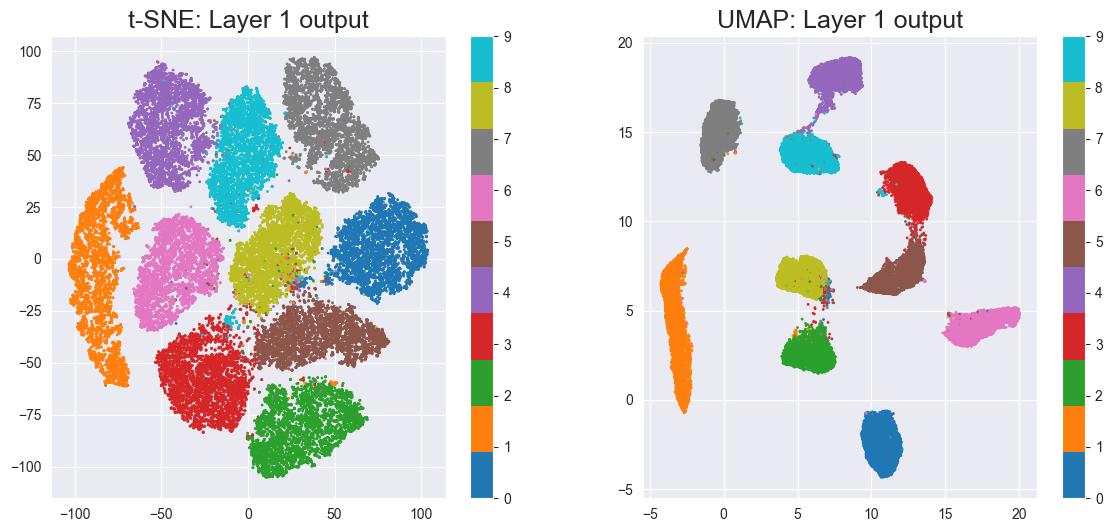

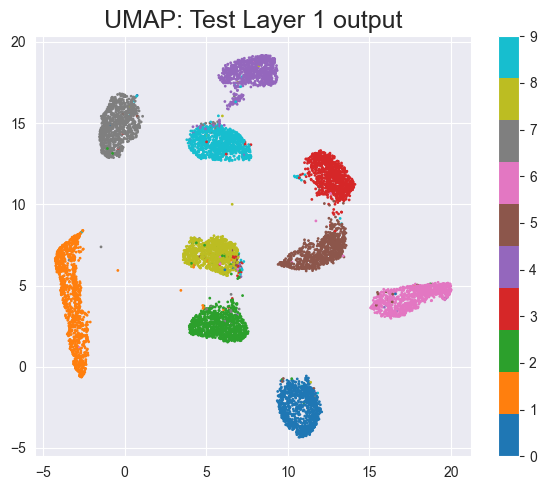

Layer 1 output Data UMAP Embeddings:
n_neighbors=1, Accuracy: 0.9636
n_neighbors=3, Accuracy: 0.9696
n_neighbors=5, Accuracy: 0.9705
n_neighbors=7, Accuracy: 0.9707
n_neighbors=10, Accuracy: 0.9707
n_neighbors=15, Accuracy: 0.9701


/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


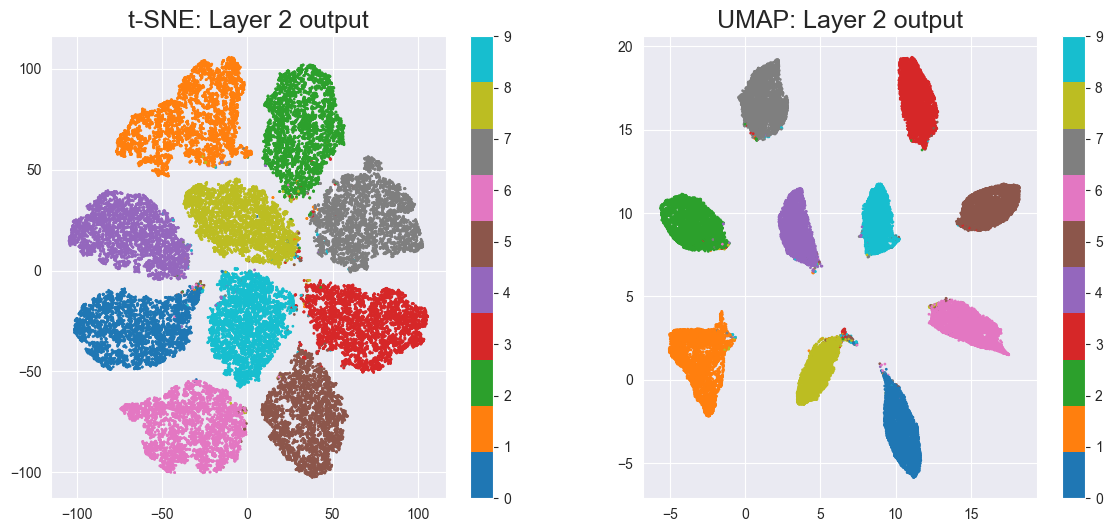

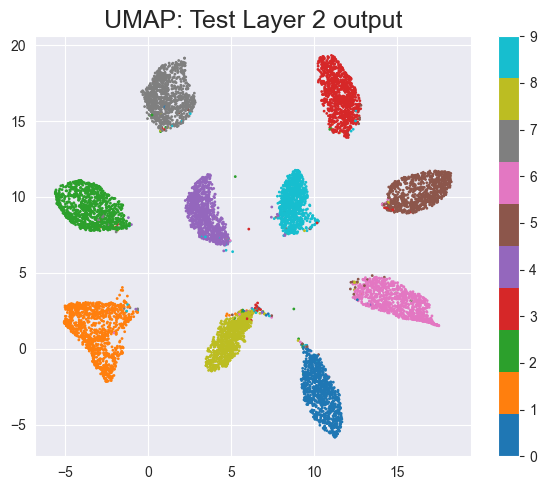

Layer 2 output Data UMAP Embeddings:
n_neighbors=1, Accuracy: 0.9741
n_neighbors=3, Accuracy: 0.9760
n_neighbors=5, Accuracy: 0.9769
n_neighbors=7, Accuracy: 0.9770
n_neighbors=10, Accuracy: 0.9773
n_neighbors=15, Accuracy: 0.9771


In [11]:
create_layer_visualization(Y_test,Y_train,layer1_output_test, layer1_output_train,title="Layer 1 output", n=5000)
create_layer_visualization(Y_test,Y_train,layer2_output_test,layer2_output_train,title="Layer 2 output", n=5000)

#### I observed that clustering based on activations from specific hidden layers gave better results than clustering on raw data. Class separation was clearer and the clusters were more compact. Additionally, clustering based on the second hidden layer performed better than the first hidden layer. This is reasonable, as deeper layers typically yield better results (though not always, since performance can degrade or overfitting can occur — but in this small network, that wasn’t the case).

#### The classification accuracy increased from the range of 0.92–0.95 for raw data to 0.974–0.977 when using activations from the second hidden layer. Accuracy was also almost always higher when using a larger n_neighbors parameter in the KNN algorithm. The difference was more noticeable for raw data than for hidden layers, since clusters in hidden layers were denser, and increasing the number of neighbors had only a slight impact on the overall quality.

# Exercise 2: Fashion-MNIST Visualization


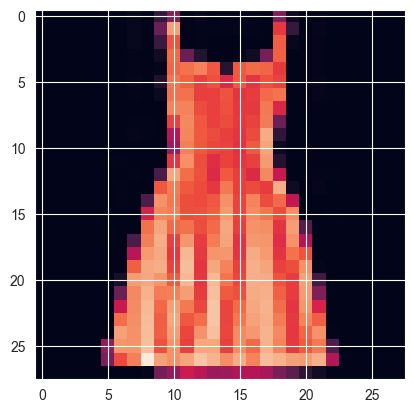

In [12]:
# Load the Fashion-MNIST dataset
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Preprocess data
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalize data
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = utils.to_categorical(y_train, 10)
Y_test = utils.to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5/6)
# Show example digit
plt.imshow(X_train[0].reshape(28, 28))


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5828 - loss: 1.1695 - val_accuracy: 0.8267 - val_loss: 0.4804
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7952 - loss: 0.5823 - val_accuracy: 0.8417 - val_loss: 0.4461
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8208 - loss: 0.5171 - val_accuracy: 0.8524 - val_loss: 0.3984
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8318 - loss: 0.4757 - val_accuracy: 0.8571 - val_loss: 0.3868
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8365 - loss: 0.4660 - val_accuracy: 0.8576 - val_loss: 0.3777
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8459 - loss: 0.4393 - val_accuracy: 0.8630 - val_loss: 0.3802
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8505 - loss: 0.4265 - val_accuracy: 0.8675 - val_loss: 0.3658
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8543 - loss: 0.4118 - val_accuracy: 0.

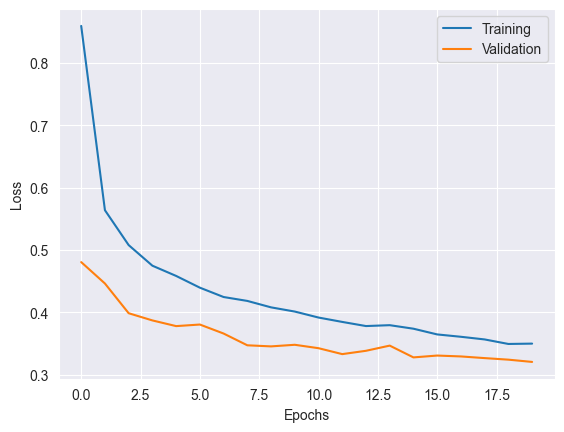

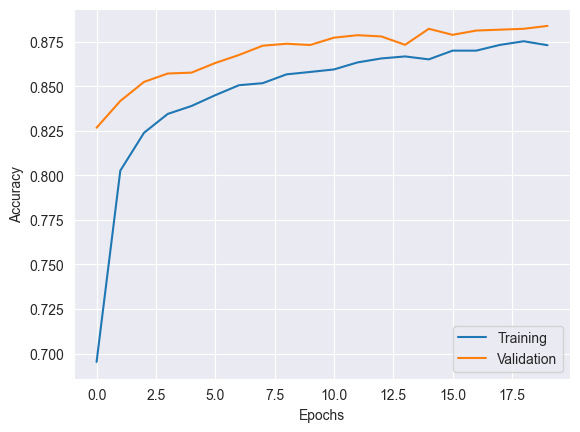

In [13]:
model = create_clasification_model()
network_history = model.fit(X_train, Y_train, batch_size=128,
                           epochs=20, verbose=1, validation_data=(X_val, Y_val))
plot_history(network_history)

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

In [15]:
layer1_output_test, layer2_output_test, layer3_output_test = get_hidden_layers_acitvations(model, X_test)
layer1_output_train, layer2_output_train, layer3_output_train = get_hidden_layers_acitvations(model, X_train)


/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


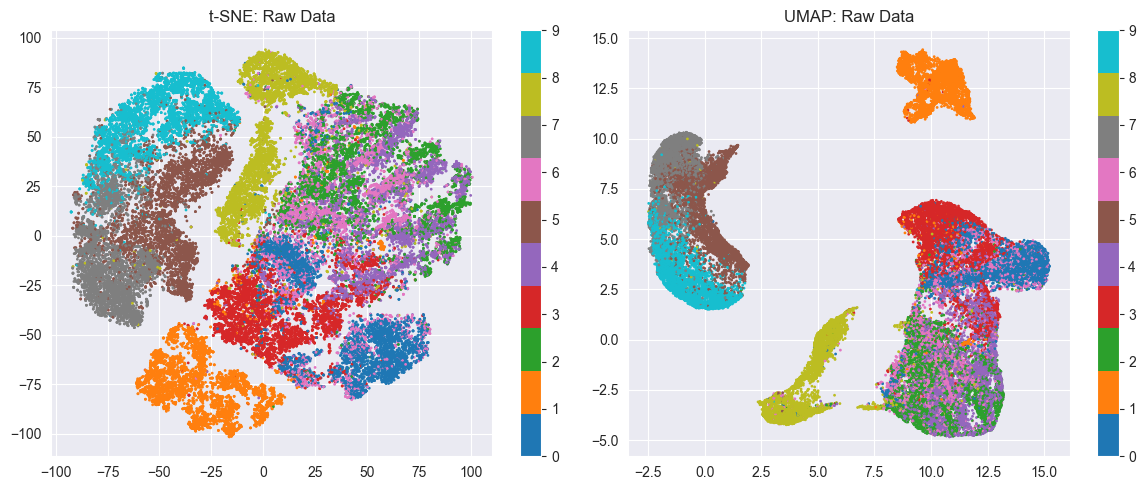

/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


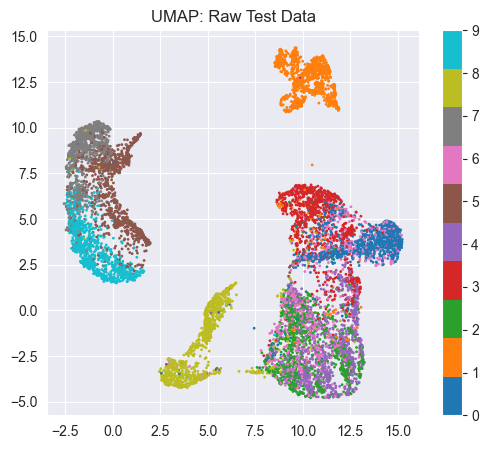

Raw Data UMAP Embeddings:
n_neighbors=1, Accuracy: 0.7102
n_neighbors=3, Accuracy: 0.7436
n_neighbors=5, Accuracy: 0.7586
n_neighbors=7, Accuracy: 0.7654
n_neighbors=10, Accuracy: 0.7700
n_neighbors=15, Accuracy: 0.7760


In [16]:
tsne_umap_raw_data(X_train,Y_train, n=5000)


/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


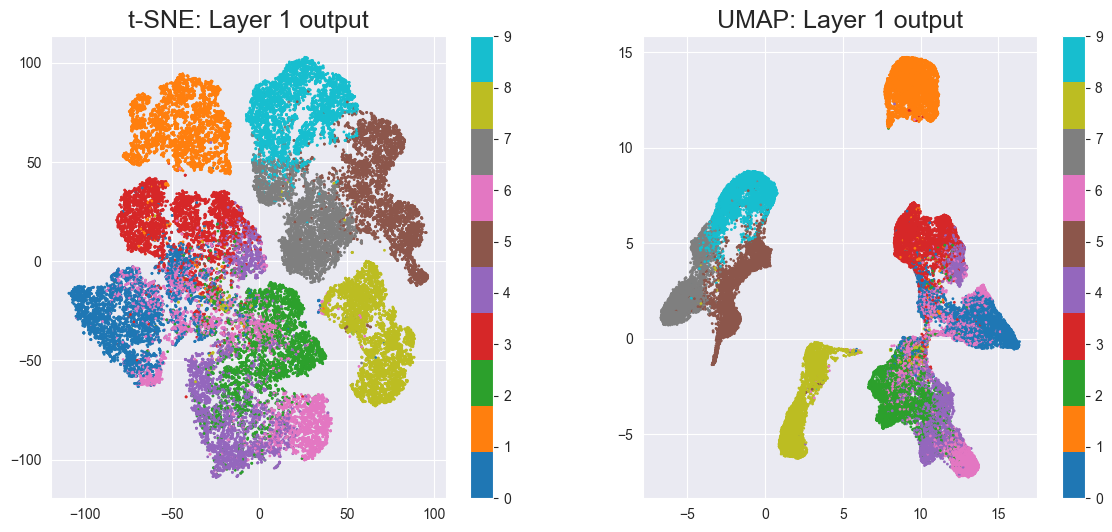

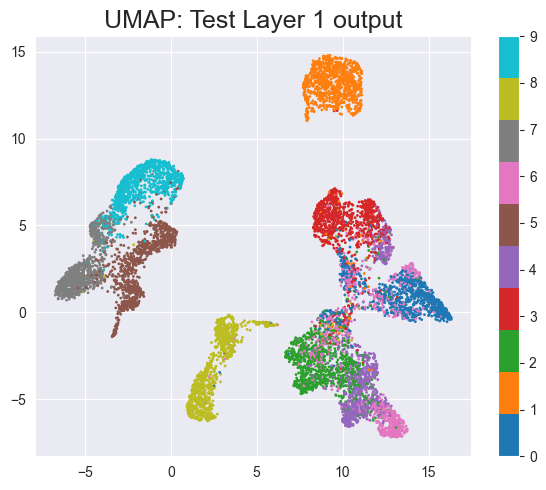

Layer 1 output Data UMAP Embeddings:
n_neighbors=1, Accuracy: 0.8252
n_neighbors=3, Accuracy: 0.8442
n_neighbors=5, Accuracy: 0.8557
n_neighbors=7, Accuracy: 0.8565
n_neighbors=10, Accuracy: 0.8581
n_neighbors=15, Accuracy: 0.8619


/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawidwozniak/studies/sem8/data_visualization/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


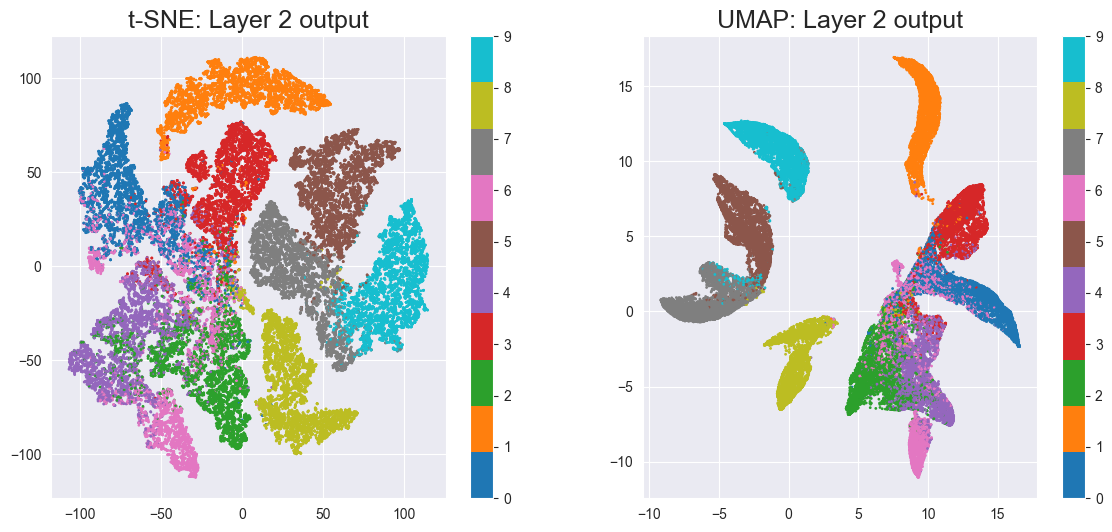

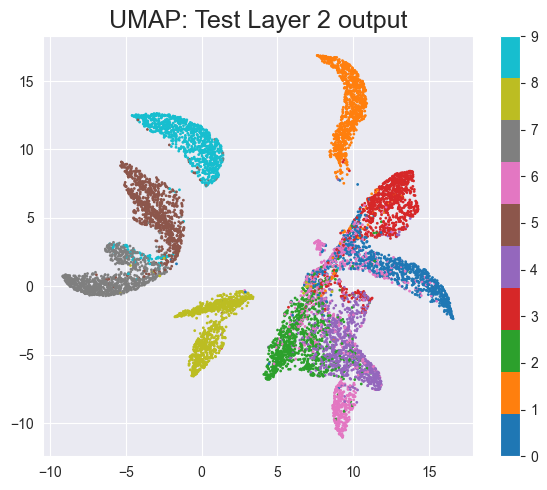

Layer 2 output Data UMAP Embeddings:
n_neighbors=1, Accuracy: 0.8241
n_neighbors=3, Accuracy: 0.8452
n_neighbors=5, Accuracy: 0.8539
n_neighbors=7, Accuracy: 0.8582
n_neighbors=10, Accuracy: 0.8602
n_neighbors=15, Accuracy: 0.8605


In [17]:
create_layer_visualization(Y_test,Y_train,layer1_output_test, layer1_output_train,title="Layer 1 output", n=5000)
create_layer_visualization(Y_test,Y_train,layer2_output_test,layer2_output_train,title="Layer 2 output", n=5000)

#### The class boundaries in Fashion MNIST turned out to be less distinct than in MNIST, which could indicate that Fashion MNIST is a more challenging dataset to model. I observed that clusters based on outputs from hidden layers were more clearly defined than those based on raw input data. The most confused and overlapping classes were 0 and 6. For Fashion MNIST, I achieved an accuracy range of 0.71–0.86, whereas for MNIST it was 0.92–0.97, confirming that the results were worse for Fashion MNIST. Hidden layers improved the accuracy more significantly for Fashion MNIST — by about 15 percentage points compared to around 5 percentage points for MNIST.

#### Based on the UMAP visualizations, the classes that benefited the most from using hidden layer activations were 9, 7, and 5 — which correspond to ankle boots, sneakers, and sandals. These were all images depicting types of footwear, so the visual similarity made classification using raw data more difficult. The neural network representations for Fashion MNIST and MNIST differed mainly in that the clusters in MNIST were more distinct and denser. This could have been due to the greater similarity and less distinguishable features of the Fashion MNIST labels, making the dataset harder to model.

#### The simple neural network I implemented likely lacked sufficient capacity to handle this complexity more effectively. I tested both t-SNE and UMAP methods, but since t-SNE does not support prediction on new data, I was only able to evaluate test set accuracy using UMAP. Therefore, I couldn't directly compare the performance of the two methods. However, based on visualizations on the training dataset, UMAP appeared to perform better in both cases. To achieve better results, especially for Fashion MNIST, I would propose adding more hidden layers or switching to a convolutional neural network architecture, which is widely used in computer vision tasks and could yield improved performance.